In [2]:
from google.colab import drive
import os

# Mount your Google Drive
drive.mount('/content/drive')

# Change the directory to your specific project folder
%cd /content/drive/MyDrive/FYP/Lecture_Hall_Occupancy

print("Current Working Directory:", os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/FYP/Lecture_Hall_Occupancy
Current Working Directory: /content/drive/MyDrive/FYP/Lecture_Hall_Occupancy


Taking Snapshots of Lecture Video at 1 minute intervals

In [ ]:
import cv2
import os

video_path = 'lecture_video.mp4'
output_dir = 'snapshots'
interval_minutes = 1
max_minutes = 20

# Create the 'snapshots' directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

# Load the video
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open {video_path}. Please check the file name and path.")
else:
    # Get the Frames Per Second (FPS) of the video
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Detected Video FPS: {fps}")

    # Calculate exactly how many frames are in one minute
    frames_per_minute = int(fps * 60)

    # Loop through minutes 0 to 20
    for current_minute in range(max_minutes + 1):

        # Calculate the exact frame number to jump to
        target_frame = current_minute * frames_per_minute

        # Tell OpenCV to jump directly to that specific frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)

        # Read the frame at that position
        ret, frame = cap.read()

        if ret:
            # Create a clean filename (e.g., snapshot_00m.jpg, snapshot_01m.jpg)
            filename = f"snapshot_{current_minute:02d}m.jpg"
            filepath = os.path.join(output_dir, filename)

            # Save the image
            cv2.imwrite(filepath, frame)
            print(f"Saved: {filepath}")
        else:
            print(f"Warning: Could not read frame at minute {current_minute}. Is the video shorter than 20 mins?")
            break

# 4. Clean up
cap.release()
print("\nExtraction complete! Check the 'snapshots' folder in your Colab files.")

Detected Video FPS: 16.667690235899823
Saved: snapshots/snapshot_00m.jpg
Saved: snapshots/snapshot_01m.jpg
Saved: snapshots/snapshot_02m.jpg
Saved: snapshots/snapshot_03m.jpg
Saved: snapshots/snapshot_04m.jpg
Saved: snapshots/snapshot_05m.jpg
Saved: snapshots/snapshot_06m.jpg
Saved: snapshots/snapshot_07m.jpg
Saved: snapshots/snapshot_08m.jpg
Saved: snapshots/snapshot_09m.jpg
Saved: snapshots/snapshot_10m.jpg
Saved: snapshots/snapshot_11m.jpg
Saved: snapshots/snapshot_12m.jpg
Saved: snapshots/snapshot_13m.jpg
Saved: snapshots/snapshot_14m.jpg
Saved: snapshots/snapshot_15m.jpg
Saved: snapshots/snapshot_16m.jpg
Saved: snapshots/snapshot_17m.jpg
Saved: snapshots/snapshot_18m.jpg
Saved: snapshots/snapshot_19m.jpg
Saved: snapshots/snapshot_20m.jpg

Extraction complete! Check the 'snapshots' folder in your Colab files.


Take snapshots and crop for Lecture Hall view

In [8]:
import cv2
import os

# --- Configuration ---
input_dir = 'lecture_hall_144'
output_dir = 'snapshots_cropped'
max_minutes = 20

# CROP CONFIGURATION
X_START_PCT = 0.75
Y_START_PCT = 0.75

os.makedirs(output_dir, exist_ok=True)

# Find all .mp4 files in the new input directory
video_files = [f for f in os.listdir(input_dir) if f.endswith('.mp4')]

if not video_files:
    print(f"No .mp4 videos found in the '{input_dir}' directory. Please check your folder.")
else:
    print(f"Found {len(video_files)} video(s). Starting extraction...")

    # Loop through every video found in the folder
    for video_filename in video_files:
        video_path = os.path.join(input_dir, video_filename)

        # Get the video name without the '.mp4' extension to use for naming snapshots
        video_base_name = os.path.splitext(video_filename)[0]

        print(f"\n--- Processing: {video_filename} ---")
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            print(f"Error: Could not open {video_path}. Skipping.")
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frames_per_minute = int(fps * 60)

        # Read the first frame just to get dimensions for the crop calculations
        ret, test_frame = cap.read()
        if ret:
            height, width, _ = test_frame.shape
            start_y = int(height * Y_START_PCT)
            end_y = height
            start_x = int(width * X_START_PCT)
            end_x = width
        else:
            print(f"Warning: Could not read the first frame of {video_filename}. Skipping video.")
            cap.release()
            continue

        # Extract frames from minute 0 to max_minutes
        for current_minute in range(max_minutes + 1):
            target_frame = current_minute * frames_per_minute
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()

            if ret:
                # --- NEW LOGIC: Check if it's the very first snapshot ---
                if current_minute == 0:
                    # Save the FULL, uncropped frame to use as a structural background reference
                    filename = f"{video_base_name}_snapshot_{current_minute:02d}m_full.jpg"
                    filepath = os.path.join(output_dir, filename)
                    cv2.imwrite(filepath, frame)
                    print(f"Saved: {filepath} (Uncropped Reference)")
                else:
                    # Apply the crop for all subsequent frames
                    cropped_frame = frame[start_y:end_y, start_x:end_x]
                    filename = f"{video_base_name}_snapshot_{current_minute:02d}m_cropped.jpg"
                    filepath = os.path.join(output_dir, filename)
                    cv2.imwrite(filepath, cropped_frame)
                    print(f"Saved: {filepath}")
            else:
                print(f"Finished reading {video_filename} at minute {current_minute}.")
                break

        cap.release()

print(f"\nExtraction complete! Check the '{output_dir}' folder.")

Found 1 video(s). Starting extraction...

--- Processing: lecture_video.mp4 ---
Saved: snapshots_cropped/lecture_video_snapshot_00m_full.jpg (Uncropped Reference)
Saved: snapshots_cropped/lecture_video_snapshot_01m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_02m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_03m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_04m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_05m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_06m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_07m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_08m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_09m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_10m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_11m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_12m_cropped.jpg
Saved: snapshots_cropped/lecture_video_snapshot_13m_cropped.jpg
Saved

In [10]:
!pip install ultralytics seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.7 MB/s eta 0:00:00


Generating Heatmap through aggregation of (x,y) coords from cropped snapshots

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# --- Configuration ---
image_folder = 'snapshots_cropped'
# We use 'yolov8s.pt' (Small). It's a great balance of speed and accuracy.
# It will automatically download the model weights the first time you run this.
model = YOLO('yolov8s.pt')

# List to hold the (x, y) coordinates of every detected student
all_student_points = []

print("Starting student detection across all frames...")

# 1. Loop through all images in your folder alphabetically
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.jpg')])

for filename in image_files:
    filepath = os.path.join(image_folder, filename)

    # Run YOLOv8 inference on the image
    # verbose=False stops it from printing a log for every single image
    results = model(filepath, verbose=False)

    # 2. Extract bounding boxes
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Class 0 in the COCO dataset is 'person'
            if int(box.cls[0]) == 0:
                # Extract the coordinates of the bounding box
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                # Calculate the center point of the person
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2

                # Save the point
                all_student_points.append([center_x, center_y])

print(f"Detection complete! Found {len(all_student_points)} total student instances across the 20 minutes.")

# 3. Generate the Heatmap Visualization
if len(all_student_points) > 0:
    print("Generating heatmap...")

    # Separate X and Y coordinates for plotting
    x_coords = [p[0] for p in all_student_points]
    y_coords = [p[1] for p in all_student_points]

    # Load the very first image to use as the background
    first_image_path = os.path.join(image_folder, image_files[0])
    bg_img = cv2.imread(first_image_path)
    bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB) # Convert for Matplotlib

    # Setup the plot
    plt.figure(figsize=(12, 8))
    plt.imshow(bg_img)

    # Use Seaborn's KDE plot to create a smooth heatmap overlay
    # cmap="magma" or "inferno" give good standard heatmap colors (purple/orange/yellow)
    # alpha=0.6 makes it semi-transparent so you can see the seats underneath
    sns.kdeplot(
        x=x_coords, y=y_coords,
        cmap="magma", fill=True,
        alpha=0.6, bw_adjust=0.5, thresh=0.05
    )

    plt.title("Lecture Hall Occupancy Heatmap (First 20 Minutes)", fontsize=16)
    plt.axis('off') # Hide the axis numbers

    # Save the final heatmap back to your Drive
    plt.savefig('final_occupancy_heatmap.png', bbox_inches='tight', dpi=300)
    plt.show()

    print("Saved final_occupancy_heatmap.png to your FYP folder!")
else:
    print("No students were detected. Check the model or images.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting student detection across all frames...
Detection complete! Found 59 total student instances across the 20 minutes.
Generating heatmap...


Saved final_occupancy_heatmap.png to your FYP folder!


In [ ]:
!pip install moviepy

In [ ]:
from moviepy.editor import VideoFileClip
import os

# --- Configuration ---
video_path = 'lecture_video.mp4'
# Saving as .wav is highly recommended if you plan to do audio analysis or transcription later
audio_output = 'lecture_audio.wav'

if not os.path.exists(video_path):
    print(f"Error: Could not find {video_path}. Make sure you are in the correct FYP directory.")
else:
    print(f"Extracting audio from {video_path}...")

    # Load the video file
    video_clip = VideoFileClip(video_path)

    # Extract the audio component
    audio_clip = video_clip.audio

    # Write the audio to a file
    # logger=None stops it from printing a massive progress bar in Colab
    audio_clip.write_audiofile(audio_output, logger=None)

    # Clean up memory
    audio_clip.close()
    video_clip.close()

    print(f"\nSuccess! Audio saved as '{audio_output}' in your current folder.")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Extracting audio from lecture_video.mp4...

Success! Audio saved as 'lecture_audio.wav' in your current folder.


Batch Extraction (Audio & Video Snapshots)

In [ ]:
import cv2
import os
import subprocess

# --- Directory Configuration ---
video_dir = 'lecture_hall_144'
audio_dir = 'audio_files_144'
snapshots_dir = 'snapshots_cropped'
max_minutes = 20

# Crop Configuration
X_START_PCT = 0.75
Y_START_PCT = 0.70

# Ensure output directories exist
os.makedirs(audio_dir, exist_ok=True)
os.makedirs(snapshots_dir, exist_ok=True)

# Get all mp4 files in the directory
video_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]

if not video_files:
    print(f"No .mp4 files found in {video_dir}. Please check your folder.")
else:
    print(f"Found {len(video_files)} lecture videos. Starting batch processing...\n")

    for video_filename in video_files:
        video_path = os.path.join(video_dir, video_filename)
        # Get the filename without the .mp4 extension to use as a prefix
        base_name = os.path.splitext(video_filename)[0]

        print(f"--- Processing: {video_filename} ---")

        # ==========================================
        # 1. AUDIO EXTRACTION (Using FFmpeg)
        # ==========================================
        audio_output = os.path.join(audio_dir, f"{base_name}_audio.wav")
        print(f"Extracting audio to {audio_output}...")

        # We use subprocess to run the FFmpeg command silently in the background
        command = ['ffmpeg', '-i', video_path, '-q:a', '0', '-map', 'a', audio_output, '-y']
        subprocess.run(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # ==========================================
        # 2. SNAPSHOT EXTRACTION & CROPPING
        # ==========================================
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Failed to open {video_filename} for image extraction. Skipping.")
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frames_per_minute = int(fps * 60)

        # Get dimensions for crop from the very first frame
        ret, test_frame = cap.read()
        if ret:
            height, width, _ = test_frame.shape
            start_y = int(height * Y_START_PCT)
            end_y = height
            start_x = int(width * X_START_PCT)
            end_x = width

        print("Extracting 20 minute snapshots...")
        for current_minute in range(1, max_minutes + 1):
            target_frame = current_minute * frames_per_minute
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()

            if ret:
                cropped_frame = frame[start_y:end_y, start_x:end_x]

                # Naming format: [video_name]_snapshot_[minute]m.jpg
                snap_filename = f"{base_name}_snapshot_{current_minute:02d}m.jpg"
                snap_filepath = os.path.join(snapshots_dir, snap_filename)

                cv2.imwrite(snap_filepath, cropped_frame)
            else:
                break # Video might be shorter than 20 mins

        cap.release()
        print("Done.\n")

print("Batch processing complete! All audio and snapshots are extracted.")

Found 1 lecture videos. Starting batch processing...

--- Processing: lecture_video.mp4 ---
Extracting audio to audio_files_144/lecture_video_audio.wav...
Extracting 20 minute snapshots...


KeyboardInterrupt: 

YOLO Detection & Anonymized Heatmap

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Step 1: Running YOLOv8 detection to build point cloud and blur zones...
Found 59 total student instances.

Step 2: Creating smooth alpha-blended anonymized background...

Step 3: Generating final heatmap plot...


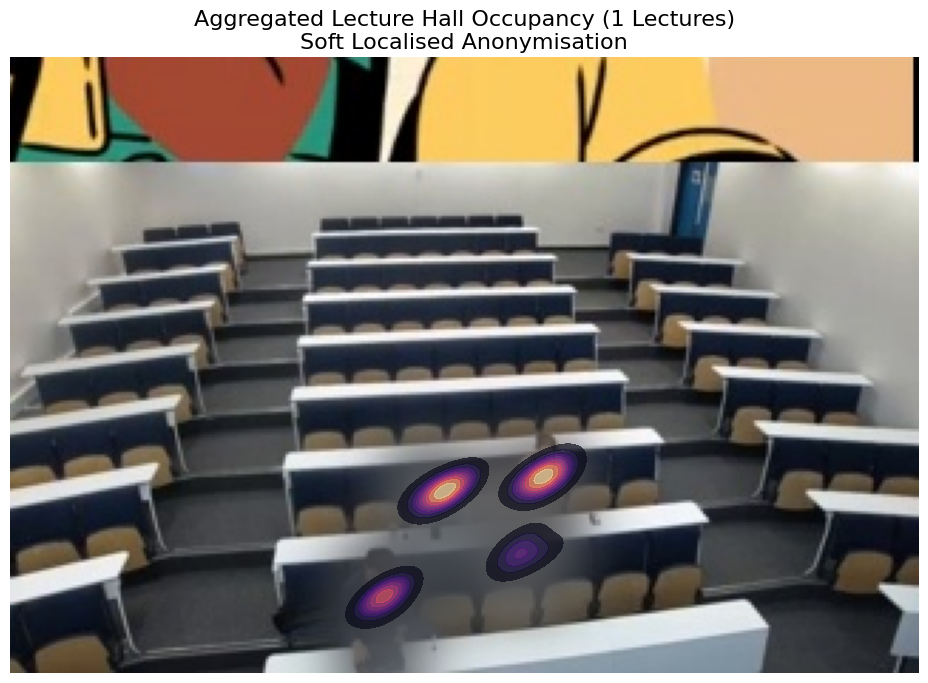

Saved final_anonymized_heatmap.png to your current folder!


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# --- Configuration ---
snapshots_dir = 'snapshots_cropped'
model = YOLO('yolov8s.pt')

all_student_points = []
all_student_boxes = [] # We now need the boxes to know how big to make the blur
image_files = sorted([f for f in os.listdir(snapshots_dir) if f.endswith('.jpg')])

if not image_files:
    print(f"No snapshots found in {snapshots_dir}.")
else:
    print("Step 1: Running YOLOv8 detection to build point cloud and blur zones...")

    for filename in image_files:
        filepath = os.path.join(snapshots_dir, filename)
        results = model(filepath, verbose=False)

        for result in results:
            boxes = result.boxes
            for box in boxes:
                if int(box.cls[0]) == 0:
                    # Extract full bounding box
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    center_x = (x1 + x2) / 2
                    center_y = (y1 + y2) / 2

                    all_student_points.append([center_x, center_y])
                    all_student_boxes.append([x1, y1, x2, y2])

    print(f"Found {len(all_student_points)} total student instances.")

    if len(all_student_points) > 0:
        print("\nStep 2: Creating smooth alpha-blended anonymized background...")

        # Load structural background
        bg_path = os.path.join(snapshots_dir, image_files[0])
        bg_img_clear = cv2.imread(bg_path)
        bg_img_clear = cv2.cvtColor(bg_img_clear, cv2.COLOR_BGR2RGB)

        # 1. Create a fully blurred version of the background
        bg_img_blurred = cv2.GaussianBlur(bg_img_clear, (99, 99), 0)

        # 2. Create a blank, floating-point mask for soft blending
        height, width, _ = bg_img_clear.shape
        mask = np.zeros((height, width), dtype=np.float32)

        # 3. Draw solid circles on the mask based on bounding box size
        for box in all_student_boxes:
            x1, y1, x2, y2 = box
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)

            # Use the width of the bounding box to size the blur, slightly inflated (1.3x)
            radius = int(((x2 - x1) / 2) * 1.3)

            # Draw a white circle (value 1.0) on the black mask
            cv2.circle(mask, (center_x, center_y), radius, 1.0, -1)

        # 4. Blur the mask itself to create feathered, soft edges
        mask = cv2.GaussianBlur(mask, (61, 61), 0)

        # Expand the 2D mask to 3 channels so it matches the image color channels
        mask_3d = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

        # 5. Alpha Blending: Mix the clear and blurred images based on the soft mask
        final_anonymized_bg = (bg_img_blurred * mask_3d + bg_img_clear * (1 - mask_3d)).astype(np.uint8)

        print("\nStep 3: Generating final heatmap plot...")

        x_coords = [p[0] for p in all_student_points]
        y_coords = [p[1] for p in all_student_points]

        plt.figure(figsize=(12, 8))

        # Display the seamlessly blended background
        plt.imshow(final_anonymized_bg)

        # Overlay the Seaborn density heatmap
        sns.kdeplot(
            x=x_coords, y=y_coords,
            cmap="magma", fill=True,
            alpha=0.65, bw_adjust=0.5, thresh=0.05
        )

        plt.title(f"Aggregated Lecture Hall Occupancy ({len(image_files)//20} Lectures)\nSoft Localised Anonymisation", fontsize=16)
        plt.axis('off')

        output_name = 'final_anonymized_heatmap.png'
        plt.savefig(output_name, bbox_inches='tight', dpi=300)
        plt.show()

        print(f"Saved {output_name} to your current folder!")

Generated Heatmap Mapped onto empty image

Empty Background: 1864x1048
Cropped Snapshot: 320x180
Calculated Scale Multiplier: X=5.825, Y=5.822

Step 1: Running YOLOv8 detection on 20 strictly cropped frames...
Found 59 total student instances.

Step 2: Generating final precisely scaled heatmap plot...


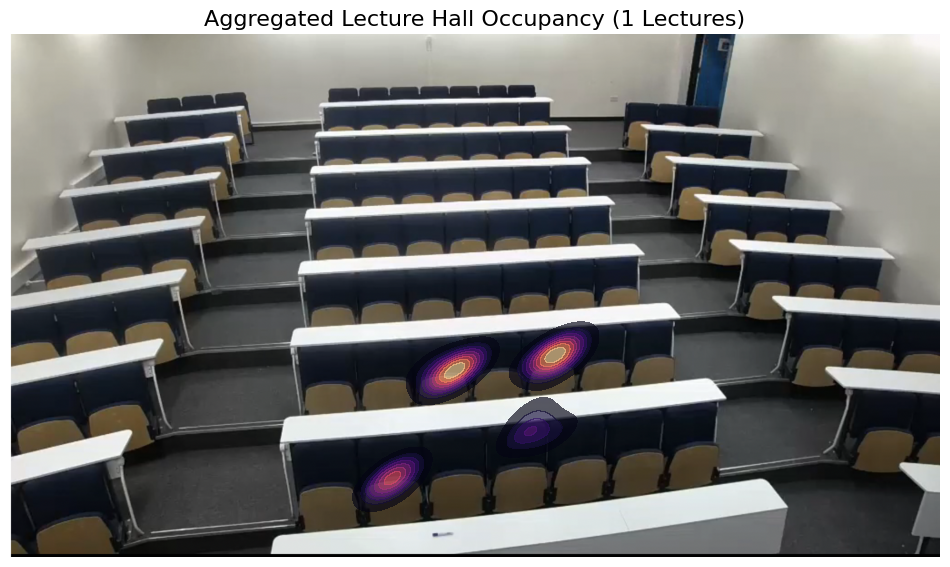

Saved 'heatmap_over_empty_lecture_hall_144.png' to your current folder!


In [18]:
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# --- Configuration ---
snapshots_dir = 'snapshots_cropped'
empty_bg_path = 'empty_lecture_hall_144.png'
model = YOLO('yolov8s.pt')

all_student_points = []

# THE CRUCIAL FIX: Explicitly target ONLY the cropped frames.
# This completely ignores the massive '_full.jpg' frame that was breaking the scale.
image_files = sorted([f for f in os.listdir(snapshots_dir) if f.endswith('_cropped.jpg')])

if not image_files:
    print(f"No cropped snapshots found in {snapshots_dir}.")
else:
    # Scaling logic for empty lecture hall screenshot
    # 1. Get dimensions of the pristine background (1864 x 1048)
    bg_img_clear = cv2.imread(empty_bg_path)
    if bg_img_clear is None:
        raise FileNotFoundError(f"Could not load background image at {empty_bg_path}")
    bg_img_clear = cv2.cvtColor(bg_img_clear, cv2.COLOR_BGR2RGB)
    bg_height, bg_width, _ = bg_img_clear.shape

    # 2. Get dimensions of a true cropped snapshot (1280 x 720)
    sample_crop_path = os.path.join(snapshots_dir, image_files[0])
    sample_crop = cv2.imread(sample_crop_path)
    crop_height, crop_width, _ = sample_crop.shape

    # 3. Calculate the correct multiplier (e.g., 1864 / 1280 = 1.456x)
    scale_x = bg_width / crop_width
    scale_y = bg_height / crop_height

    print(f"Empty Background: {bg_width}x{bg_height}")
    print(f"Cropped Snapshot: {crop_width}x{crop_height}")
    print(f"Calculated Scale Multiplier: X={scale_x:.3f}, Y={scale_y:.3f}")
    print(f"\nStep 1: Running YOLOv8 detection on {len(image_files)} strictly cropped frames...")

    for filename in image_files:
        filepath = os.path.join(snapshots_dir, filename)
        results = model(filepath, verbose=False)

        for result in results:
            boxes = result.boxes
            for box in boxes:
                if int(box.cls[0]) == 0: # Class 0 is 'person'
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    center_x = (x1 + x2) / 2
                    center_y = (y1 + y2) / 2

                    # Stretch the coordinates to fit the 1864x1048 background
                    scaled_x = center_x * scale_x
                    scaled_y = center_y * scale_y

                    all_student_points.append([scaled_x, scaled_y])

    print(f"Found {len(all_student_points)} total student instances.")

    if len(all_student_points) > 0:
        print("\nStep 2: Generating final precisely scaled heatmap plot...")

        x_coords = [p[0] for p in all_student_points]
        y_coords = [p[1] for p in all_student_points]

        plt.figure(figsize=(12, 8))

        # Display the empty lecture hall
        plt.imshow(bg_img_clear)

        # Overlay the Seaborn density heatmap
        sns.kdeplot(
            x=x_coords, y=y_coords,
            cmap="magma", fill=True,
            alpha=0.65, bw_adjust=0.5, thresh=0.05
        )

        num_lectures = max(1, len(image_files) // 20)
        plt.title(f"Aggregated Lecture Hall Occupancy ({num_lectures} Lectures)", fontsize=16)
        plt.axis('off')

        output_name = 'heatmap_over_empty_lecture_hall_144.png'
        plt.savefig(output_name, bbox_inches='tight', dpi=300)
        plt.show()

        print(f"Saved '{output_name}' to your current folder!")
    else:
        print("No students were detected in the snapshots.")

diagnostics

In [17]:
import cv2
import os

snapshots_dir = 'snapshots_cropped'
empty_bg_path = 'empty_lecture_hall_144.png'

# 1. Get background dimensions
bg_img = cv2.imread(empty_bg_path)
if bg_img is not None:
    print(f"Empty Background Dimensions: {bg_img.shape[1]}x{bg_img.shape[0]} (Width x Height)")
else:
    print("Could not load background image.")

# 2. Get cropped snapshot dimensions
image_files = [f for f in os.listdir(snapshots_dir) if f.endswith('.jpg')]
if image_files:
    sample_crop = cv2.imread(os.path.join(snapshots_dir, image_files[0]))
    print(f"Cropped Snapshot Dimensions: {sample_crop.shape[1]}x{sample_crop.shape[0]} (Width x Height)")
else:
    print("No cropped snapshots found.")

Empty Background Dimensions: 1864x1048 (Width x Height)
Cropped Snapshot Dimensions: 1280x720 (Width x Height)
